In [1]:
import numpy as np
import scipy.constants as const
from scipy.integrate import solve_ivp, trapezoid, simpson
from scipy.optimize import root_scalar, least_squares
import matplotlib.pyplot as plt
# ----------------- cosmological parameters -----------------
c_km_s = const.c/1000
c = const.c            # km/s
G = const.G              # SI
Mpc_to_km = const.parsec * 1e6 / 1000
sigma_boltzmann = const.sigma
hbar = const.hbar
k_b = const.k

kappa2 = 8*np.pi*G

### Photon and Neutrino density

The physical density $\rho_{\gamma}^{\text{phys}}$ using the Stefan-Boltzmann constant $\sigma_B$: 
$$
\rho_{\gamma,0}^{\text{phys}} = \frac{4 \sigma_B}{c^3} T_{\text{cmb}}^4
$$
Note: The factor 4 comes from converting the Stefan-Boltzmann flux formula $\sigma T^4$ into energy density $4/c \cdot \sigma T^4$.

Now convert to $\Omega_{\gamma}$:

$$
\Omega_{\gamma,0} = \frac{\rho_{\gamma,0}^\text{phys}}{\rho_{\text{crit,0}}}
$$

Then calculate the photon density in CLASS units:

$$
\rho_{\gamma,0}^\text{class} = \Omega_{\gamma,0} H_0^2
$$

So the effective formula used at any redshift $z$ is 
$$
\rho_{\gamma}^{\text{class}}(z) = \rho_{\gamma,0}^\text{class}(1+z)^4 = \Omega_{\gamma, 0} H_0^2 (1+z)^4
$$

Neutrino density formula:

$$
\rho_{\nu }=N_{\text{eff}}\frac{7}{8}\left(\frac{4}{11}\right)^{4/3}\rho_\gamma
$$

Defines the "effective number of relativistic species" $N_{\text{ur}}$ (typically 3.046 for standard cosmology). 
The $\Omega_{\text{ur}}$ today is

$$
\Omega_{\text{ur}} = N_{\text{ur}} \frac{7}{8} \left( \frac{4}{11} \right)^{4/3} \Omega_{\gamma}
$$

So the neutrino density in CLASS units is
$$
\rho_{\nu,0}^\text{class} = \Omega_{\text{ur,0}} H_0^2
$$

And the effective formula used at any redshift $z$ is
$$
\rho_{\nu}^\text{class}(z) = \rho_{\nu,0}^\text{class}(1+z)^4 = \Omega_{\text{ur,0}} H_0^2 (1+z)^4
$$


In [2]:
Tcmb = 2.72548 # CMB temperature in SI units
N_ur = 3.046 

# NEW: Use Physical Densities (Planck 2018)
omega_b_phys = 0.02237
omega_cdm_phys = 0.1200

delta = 0.103
lambda_phi = 0.1

h = 0.69  

def H0h(h): return 100*h

H0 = H0h(h)
H0_SI = H0 / Mpc_to_km
H0_class = H0/c_km_s   

H0_phys = H0_SI # H0 in SI units

# physical critical density at z = 0
rho_crit0_phys = 3.0 * H0_phys**2 / (8.0 * np.pi * G)

# CLASS critical density at z = 0
rho_crit0 = H0_class * H0_class

# physical density of photons at z = 0
rho_gamma_phys = 4*sigma_boltzmann/c/c/c * Tcmb**4

# photon density parameter at z = 0
Omega_gamma0 = rho_gamma_phys/rho_crit0_phys

# neutrino density parameter at z = 0
Omega_nu0 = N_ur * 0.875 * (4.0/11.0)**(4.0/3) *Omega_gamma0

# radiation density parameter at z = 0
Omega_rad0 = Omega_gamma0 + Omega_nu0

# Calculate Omega parameters from physical densities
Omega_b0 = omega_b_phys / h**2
Omega_cdm0 = omega_cdm_phys / h**2
Omega_m0 = Omega_b0 + Omega_cdm0

# dark energy density parameter at z = 0 (flat)
Omega_DE0 = 1.0 - Omega_b0 - Omega_cdm0 - Omega_rad0


def rho_gamma(N):
    return H0_class * H0_class * Omega_gamma0 * np.exp(-4*N)

def rho_nu(N):
    return H0_class * H0_class * Omega_nu0 * np.exp(-4*N)

def rho_rad(N):
    return rho_gamma(N) + rho_nu(N)

def rho_b(N):
    return H0_class * H0_class * Omega_b0 * np.exp(-3*N)

def rho_cdm(N):
    return H0_class * H0_class * Omega_cdm0 * np.exp(-3*N)

def rho_m(N):
    return rho_b(N) + rho_cdm(N)

dens_param = {
    "Omega_b0": Omega_b0,
    "Omega_cdm0": Omega_cdm0,
    "Omega_m0": Omega_m0,
    "Omega_gamma0": Omega_gamma0,
    "Omega_nu0": Omega_nu0,
    "Omega_rad0": Omega_rad0,
    "Omega_DE0": Omega_DE0,
}

for key, value in dens_param.items():
    print(f"{key} = {value}")


Omega_b0 = 0.04698592732619199
Omega_cdm0 = 0.25204788909892883
Omega_m0 = 0.29903381642512084
Omega_gamma0 = 5.1940826333151916e-05
Omega_nu0 = 3.593104775703192e-05
Omega_rad0 = 8.787187409018383e-05
Omega_DE0 = 0.700878311700789


In [3]:

a_ini = 1.0e-14
a_0 = 1.0
N_ini = np.log(a_ini)
N_0 = 0.0
N_final = N_0

# a and N tables
a_table = np.logspace(np.log10(a_ini), a_0, 5000)
N_table = np.log(a_table)

# RENAMED: density_dict -> densities (as requested)
densities = {
    "rho_gamma": rho_gamma,
    "rho_nu": rho_nu,
    "rho_rad": rho_rad,
    "rho_b": rho_b,
    "rho_cdm": rho_cdm,
    "rho_m": rho_m,
}

#---------- Some initial values in radiation dominated era -----
rho_rad_RD = densities["rho_rad"](N_ini) # radiation density in radiation era
rho_b_RD = densities["rho_b"](N_ini) # baryon density in radiation era
rho_cdm_RD = densities["rho_cdm"](N_ini) # cdm density in radiation era
rho_m_RD = densities["rho_m"](N_ini) # matter density in radiation era

for key, func in densities.items():
    print(f"{key}_RD = {func(N_ini)}")

rho_gamma_RD = 2.751475374191435e+44
rho_nu_RD = 1.903385064347135e+44
rho_rad_RD = 4.65486043853857e+44
rho_b_RD = 2.4889981753919364e+33
rho_cdm_RD = 1.3351800672643378e+34
rho_m_RD = 1.5840798848035315e+34


### Scalar field value in radiation-dominated universe

$$
Q(\delta, \lambda_\phi) = 
\left\{
\begin{align}
& \frac{24\delta^2 - \lambda_\phi^2}{\lambda_\phi^2 + 6\delta^2(\lambda_\phi^2 - 4)} \quad \text{if } \delta \neq 0 \qquad \\
& \frac{4}{\lambda_\phi^2 - 4}  \hspace{5.5em}\text{if } \delta = 0
\end{align}
\right.
$$

Scalar field value in RD (pure scalar field, $\delta = 0$) is defined as 

$$
\phi_{RD} = - \frac{1}{\lambda_\phi} \ln\left(\frac{4}{3\lambda_\phi^2-12}\right)\rho_{rad}
$$

In case of $\delta \neq 0$, we have

$$
\phi_{RD} = - \frac{1}{\lambda_\phi} \ln\left(\frac{1}{3}Q(\delta, \lambda_\phi)\,\rho_{rad}\right)
$$

### Scalar field potential in radiation-dominated universe

$$
V_{RD} = V(\phi_{RD}) = \frac{1}{3} Q(\delta, \lambda_\phi) \,\rho_{rad}
$$

For $\delta \neq 0$, we have

$$
V_{RD} = V(\phi_{RD}) = \frac{4}{3\lambda_\phi^2-12} \,\rho_{rad}
$$



In [4]:
phi_ini = 1.0
phi_prime_ini = 1.0

def Q(delta,lambda_phi):
    if (delta != 0):
        qq = (24.0*delta**2 - lambda_phi**2) / (lambda_phi**2 + 6.0*delta**2*(lambda_phi**2 - 4.0))
        return qq
    else:
        val = 4.0 / (lambda_phi**2 - 4.0)
        return val

def V_phi_RD(delta, lambda_phi):
    return Q(delta,lambda_phi) / 3.0 * rho_rad_RD

def phi_RD_func(delta, lambda_phi):
    q_val = Q(delta,lambda_phi)
    if q_val > 0.0 :
        res = -1.0/lambda_phi * np.log(q_val/3 * rho_rad_RD) * phi_ini
    else:
        res = 1.0/lambda_phi
    return res

def phi_prime_RD_func(delta, lambda_phi):
    VphiRD = V_phi_RD(delta, lambda_phi)
    if VphiRD > 0.0:
        return 2.0 * a_ini * np.sqrt(V_phi_RD(delta, lambda_phi)) * phi_prime_ini
    else:
        return 1.0

### Derivative of Scalar field in RD

This is the conformal time derivative of the scalar field in the RD

$$
\phi'_{RD} = \pm 2a_{ini}\sqrt{V(\phi_{RD})}
$$

The scalar field density in RD is given by ()

$$
\rho_{\phi}^{RD} = \frac{1}{2a^2_{ini}}\phi'^{2}_{RD} + V(\phi_{RD})
$$

Note that the scalar field density in CLASS convention is given by

$$
\rho_{\phi}^{RD,class} = \frac{1}{3}\rho_{\phi}^{RD} =  \frac{1}{3}\left[\frac{\phi'^{2}_{RD}}{2a^2_{ini}} + V(\phi_{RD})\right]
$$


In [5]:
def initial_conditions_in_radiation_era(V0_param, delta, lambda_phi, N_ini=N_ini):
    a_ini = np.exp(N_ini)
    rho_crit0_val = H0_class**2
    
    # Calculate initial densities 
    rho_r_RD = rho_crit0_val * Omega_rad0 * np.exp(-4 * N_ini)
    rho_m_RD = rho_crit0_val * Omega_m0 * np.exp(-3 * N_ini) # Use no coupling function back-scaling to the radiation era
    
    # Thawing Model: Field is frozen early on.
    phi_RD = phi_RD_func(delta,lambda_phi)
    phi_prime_RD = phi_prime_RD_func(delta,lambda_phi)
    sigma_RD = 0.0
    sigma_prime_RD = 0.0
    
    # Optimization: rho_r is analytical, so we don't include it in y_ini
    y_ini = [rho_m_RD, phi_RD, phi_prime_RD, sigma_RD, sigma_prime_RD]
    return y_ini


---
### Derivation of Decoupling Redshift ($z_{dec}$) from Visibility Function

The decoupling of photons from baryons is not instantaneous. We define the **visibility function** $g(\eta)$ as the probability density that a photon last scattered at conformal time $\eta$.

$$
g(\eta) = -\dot{\tau} e^{-\tau}
$$

where $\tau(\eta)$ is the optical depth (opacity) back from today ($\eta_0$) to $\eta$:

$$
\tau(\eta) = \int_{\eta}^{\eta_0} a n_e \sigma_T d\eta'
$$

Here:
*   $n_e$ is the free electron number density.
*   $\sigma_T$ is the Thomson scattering cross-section ($6.65 \times 10^{-29} \text{ m}^2$).
*   $a$ is the scale factor.

In terms of redshift $z$:

$$
\tau(z) = \int_0^z n_e(z') \sigma_T \frac{dt}{dz'} dz' = \int_0^z \frac{n_e(z') \sigma_T}{(1+z') H(z')} dz'
$$

The visibility function in terms of $z$:

$$
g(z) = \frac{d\tau}{dz} e^{-\tau(z)} = \frac{n_e(z) \sigma_T}{(1+z) H(z)} e^{-\tau(z)}
$$

The **decoupling redshift** $z_{dec}$ is conventionally defined as the maximum of the visibility function:

$$
\left. \frac{dg}{dz} \right|_{z=z_{dec}} = 0
$$

To calculate $n_e(z)$, we need the ionization fraction $X_e = n_e / n_H$.
For equilibrium recombination (valid for high $z$), we can use the **Saha Equation**:

$$
\frac{X_e^2}{1-X_e} = \frac{1}{n_b} \left( \frac{m_e k_B T_b}{2\pi \hbar^2} \right)^{3/2} \exp\left( - \frac{\epsilon_0}{k_B T_b} \right)
$$

where $\epsilon_0 = 13.6$ eV is the ionization energy of hydrogen.

---
### Peebles Recombination Model

The ionization fraction $X_e$ evolution is governed by the Peebles' three-level atom model (Peebles 1968), including a "fudge factor" $F$ to approximate multi-level atom corrections.

The differential equation for the free electron fraction is:
$$
\frac{dX_e}{dt} = - C_r \left[ \alpha_B(T_m) n_H X_e^2 - \beta(T_m) (1-X_e) e^{-E_{Ly\alpha}/k_B T_m} \right]
$$
where the modified Peebles' $C_r$ factor is given by:
$$
C_r = F \times \frac{\Lambda_\alpha + \Lambda_{2s}}{\Lambda_\alpha + \Lambda_{2s} + \beta^{(2)}(T_m)}
$$
with:
- $\Lambda_{2s} = 8.22458 \, s^{-1}$: Two-photon decay rate from 2s to 1s.
- $\Lambda_\alpha = \frac{8 \pi H(z)}{\lambda_{Ly\alpha}^3 n_H (1-X_e)}$: Rate of Lyman-$\alpha$ escape due to expansion.
- $\beta^{(2)}(T_m)$: Ionization rate from the 2s state.

The matter temperature $T_m$ evolves via Compton scattering with CMB photons:
$$
\frac{dT_m}{dt} = -2 H(z) T_m + \frac{8 \sigma_T a_R T_{CMB}^4}{3 m_e c} (T_{CMB} - T_m) X_e
$$



### Sound Horizon ($r_s$), Angular Diameter Distance ($D_A$) and $\theta_s$

The sound speed is given by $c_s = 1/\sqrt{3(1+R)}$ where $R = 3\Omega_b / (4\Omega_\gamma)$.

The comoving sound horizon $r_s$ is:
$$
r_s = \int_0^{a_{dec}} \frac{c_s}{a H} dN
$$

The comoving distance to the last scattering surface $\chi(z_{dec})$ (or $D_A^{com}$) is:
$$
\chi(z_{dec}) = \int_{a_{dec}}^{1} \frac{1}{a H} dN
$$

The physical angular diameter distance is $D_A = a_{dec} \chi(z_{dec})$.

The angular size of the sound horizon is:
$$
\theta_s = \frac{r_s}{\chi(z_{dec})}
$$

In [6]:
# --- Peebles Recombination import from the script: peebles_recombination.py ---
from peebles_recombination import calculate_z_dec_peebles

# --- H0 Helper ---
def H0h(h): 
    return 100*h

# --- Update Cosmology Function ---
def update_cosmology(h_val):
    # Recalculate ALL derived parameters based on h_val
    # CONSTANTS DEFINED LOCALLY TO ENSURE UNITS CORRECTNESS
    c_SI = 299792458.0
    c_km_s = c_SI / 1000.0
    Mpc_to_km = 3.08567758e19
    G_SI = 6.67430e-11
    sigma_boltzmann_SI = 5.670374419e-8
    Tcmb_val = 2.72548
    
    H0_val = H0h(h_val)  # km/s/Mpc
    H0_SI = H0_val / Mpc_to_km   # 1/s
    H0_class_val = H0_val / c_km_s    # 1/Mpc (dimensionless if c=1 in dist units, but here we work in Mpc)
    
    # Physical density in SI (kg/m^3)
    rho_crit0_phys = 3.0 * H0_SI**2 / (8.0 * np.pi * G_SI)
    rho_gamma_phys = 4 * sigma_boltzmann_SI / c_SI**3 * Tcmb_val**4
    
    # Omega Gamma (dimensionless ratio)
    Omega_gamma0_val = rho_gamma_phys / rho_crit0_phys
    
    # Omega Nu
    Omega_nu0_val = N_ur * 0.875 * (4.0/11.0)**(4.0/3) * Omega_gamma0_val
    Omega_rad0_val = Omega_gamma0_val + Omega_nu0_val
    
    return {
        'h': h_val,
        'H0': H0_val,
        'H0_class': H0_class_val,
        'Omega_gamma0': Omega_gamma0_val,
        'Omega_nu0': Omega_nu0_val,
        'Omega_rad0': Omega_rad0_val,
        'Omega_b0': omega_b_phys / h_val**2,
        'Omega_cdm0': omega_cdm_phys / h_val**2,
        'Omega_m0': (omega_b_phys + omega_cdm_phys) / h_val**2,
    }


## Quintom model -- System of differential equations

\begin{align}
\rho_m' + 3\mathcal{H}\rho_m &= \delta\rho_m\, \sigma', \\[6pt]
\rho_\sigma' + 3\mathcal{H}(\rho_\sigma + P_\sigma) &= -\delta\rho_m\, \sigma', \\[6pt]
\rho_\phi' + 3\mathcal{H}(\rho_\phi + P_\phi) &= 0, \\[6pt]
\rho_r' + 4\mathcal{H}\rho_r &= 0.
\end{align}

where

\begin{align}
\rho_\phi &= \frac{1}{2a^2}(\phi')^2 + V(\phi), \\[6pt]
\rho_\sigma &= -\frac{1}{2a^2}(\sigma')^2, \\[10pt]
P_\phi &= \frac{1}{2a^2}(\phi')^2 - V(\phi), \\[6pt]
P_\sigma &= -\frac{1}{2a^2}(\sigma')^2.
\end{align}

Note that the potential of quintessence field, $V(\phi)$, is given by

\begin{align}
V(\phi) = V_0 e^{-\lambda_\phi \phi}.
\end{align}

where $V_0$ and $\lambda_\phi$ are constants. For the phantom field, $\sigma$, in this model has only negative kinetic term. The Klein-Gordon equation for $\phi$ and $\sigma$ are given by

\begin{align}
\sigma'' + 2\mathcal{H}\sigma' &= a^2 \delta\rho_m, \\[6pt]
\phi'' + 2\mathcal{H}\phi' + a^2 V_{,\phi} &= 0.
\end{align}

### Solutions for matter (baryon + cold dark matter)


\begin{align}
\rho_m = K_m e^{\delta\, \sigma - 3 N}
\end{align}

where $K_m$ is a constant, and $N = \ln a$ is the number of e-folds.

In [7]:
def initial_conditions_in_radiation_era(V0_param, delta, lambda_phi, Km, cosmic_params, N_ini):
    # Using Scaling Solution initial conditions from analytical formulas
    phi_RD = phi_RD_func(delta, lambda_phi)
    phi_prime_RD = phi_prime_RD_func(delta, lambda_phi)
    # Phantom field initially ignored or set to static
    sigma_RD = 0.0
    sigma_prime_RD = 0.0
    return [phi_RD, phi_prime_RD, sigma_RD, sigma_prime_RD]

def ode_system(N, y, V0_param, delta, lambda_phi, Km, cosmic_params):
    phi, phi_prime, sigma, sigma_prime = y
    a = np.exp(N)
    rho_r = get_rho_r_analytical(N, cosmic_params)
    rho_m = get_rho_m_analytical(N, sigma, Km, delta, cosmic_params)
    
    arg = -lambda_phi * phi
    arg = np.clip(arg, -700, 700)
    V = V0_param * np.exp(arg)
    
    rho_phi = (0.5 * phi_prime**2 / a**2 + V) / 3.0
    rho_sigma = -0.5 * sigma_prime**2 / a**2 / 3.0
    rho_tot = rho_m + rho_r + rho_phi + rho_sigma
    if rho_tot < 0: rho_tot = 1e-30
    
    Hb = np.sqrt(rho_tot)
    H_conf = a * Hb
    
    d_phi = phi_prime / H_conf
    d_phi_prime = -2 * phi_prime + (a**2 * lambda_phi * V) / H_conf
    d_sigma = sigma_prime / H_conf
    d_sigma_prime = -2 * sigma_prime + ((a/Hb) * delta * rho_m)
    return [d_phi, d_phi_prime, d_sigma, d_sigma_prime]

def integrate_background(V0_param, Km, cosmic_params, delta, lambda_phi, N_ini=-14*2.302, N_final=0.0):
    y_ini = initial_conditions_in_radiation_era(V0_param, delta, lambda_phi, Km, cosmic_params, N_ini=N_ini)
    sol = solve_ivp(
        lambda N, y: ode_system(N, y, V0_param, delta, lambda_phi, Km, cosmic_params),
        (N_ini, N_final), y_ini, method='Radau', rtol=1e-12, atol=1e-14, dense_output=True
    )
    N_arr = np.linspace(N_ini, N_final, 30000)
    if sol.sol is None: return []
    
    sol_y = sol.sol(N_arr)
    phi_arr, phi_prime_arr, sigma_arr, sigma_prime_arr = sol_y
    a_arr = np.exp(N_arr)
    
    rho_r = get_rho_r_analytical(N_arr, cosmic_params)
    rho_m = get_rho_m_analytical(N_arr, sigma_arr, Km, delta, cosmic_params)
    
    arg = -lambda_phi * phi_arr
    V_arr = V0_param * np.exp(arg)
    rho_phi = (0.5 * phi_prime_arr**2 / a_arr**2 + V_arr) / 3.0
    rho_sigma = -0.5 * sigma_prime_arr**2 / a_arr**2 / 3.0
    rho_tot = rho_m + rho_r + rho_phi + rho_sigma
    rho_tot[rho_tot <= 0] = 1e-30
    
    Omega_m = rho_m / rho_tot
    Omega_r = rho_r / rho_tot
    Omega_phi = rho_phi / rho_tot
    Omega_sig = rho_sigma / rho_tot
    Omega_de = Omega_phi + Omega_sig

    return (N_arr, a_arr, rho_m, rho_r, rho_phi, rho_sigma, rho_tot, 
            Omega_m, Omega_r, Omega_phi, Omega_sig, Omega_de, 
            phi_arr, phi_prime_arr, sigma_arr, sigma_prime_arr)

def calculate_theta_s(N_arr, a_arr, rho_tot_arr, cosmic_params):
    # UPGRADE: Using Simpson's rule for better accuracy
    Omega_b0 = cosmic_params['Omega_b0']
    Omega_gamma0 = cosmic_params['Omega_gamma0']
    
    z_dec = calculate_z_dec_peebles(cosmic_params)
    a_dec = 1.0 / (1.0 + z_dec)
    
    R_arr = (3.0 * Omega_b0 / (4.0 * Omega_gamma0)) * a_arr
    c_s_rel = 1.0 / np.sqrt(3.0 * (1.0 + R_arr))

    H_arr = np.sqrt(rho_tot_arr) 
    
    integrand_rs = c_s_rel / (a_arr * H_arr)
    mask_rs = a_arr <= a_dec
    if np.sum(mask_rs) < 5: return 0.0, 0.0, 0.0
    # Note: simpson takes y, x
    rs_val = simpson(integrand_rs[mask_rs], x=N_arr[mask_rs])
    
    # D_A Integral
    mask_da = a_arr >= a_dec
    integrand_da = 1.0 / (a_arr * H_arr)
    r_com_val = simpson(integrand_da[mask_da], x=N_arr[mask_da])
    DA_val = a_dec * r_com_val
    
    theta_s = rs_val / r_com_val
    return rs_val, DA_val, theta_s


In [18]:
# --- Shooting Framework Definitions ---

class SimulationResult:
    def __init__(self, sol, input_params, derived_cosmo):
        self.input_params = input_params
        # Merge input_params into get_bestfit so it contains both derived and tuned params
        self.get_bestfit = derived_cosmo.copy()
        self.get_bestfit.update(input_params)
        
        # Unpack solution tuple to dictionary using a loop
        keys = [
            'N', 'a', 'rho_m', 'rho_r', 'rho_phi', 'rho_sigma', 'rho_tot',
            'Omega_m', 'Omega_r', 'Omega_phi', 'Omega_sigma', 'Omega_de',
            'phi', 'phi_prime', 'sigma', 'sigma_prime'
        ]
        self.get_vararr = {key: sol[i] for i, key in enumerate(keys)}

class UnknownParameter:
    def __init__(self, name, initial_guess, bounds, update_fn):
        self.name = name
        self.initial_guess = initial_guess
        self.bounds = bounds
        # update_fn: (params_dict, value) -> new_params_dict
        self.update_fn = update_fn
        
class Constraint:
    def __init__(self, name, target, calc_fn):
        self.name = name
        self.target = target
        # calc_fn: (sol_out, params_dict, final_cosmo) -> observed_value
        self.calc_fn = calc_fn

class ShootingManager:
    def __init__(self, unknowns, constraints, base_params):
        self.unknowns = unknowns
        self.constraints = constraints
        self.base_params = base_params.copy()
        
    def _run_simulation(self, p):
        # Bridge: Extract params and call integrate_background
        h_val = p.get('h', 0.678)
        cosmic_params = update_cosmology(h_val)
        
        # --- FIXED: Link Km to Omega_m0 for z_dec calculation ---
        Km = p.get('Km', 1e-9)
        if Km is not None:
             # Omega_m0 = rho_m0 / rho_crit0, rho_m0 approx Km
             H0_c = cosmic_params['H0_class']
             rho_crit0 = H0_c**2
             new_Om0 = Km / rho_crit0
             cosmic_params['Omega_m0'] = new_Om0
             # print(f"  [DEBUG] Updated Omega_m0 from Km: {new_Om0:.5f}")

        V0 = p.get('V0', 1e-10)
        # print(f"cosmic_params updated: {cosmic_params}")
        zdec = calculate_z_dec_peebles(cosmic_params)
        print(f"Initial z_dec = {zdec:.5f} using logV0 = {np.log10(V0)}, Km = {Km:.5e}, Omega_m={cosmic_params['Omega_m0']:.4f}, h = {h_val:.4f}")
        
        # Km extracted above
        delta = p.get('delta', 0.1)
        lam = p.get('lambda_phi', 0.1)
        N_ini = p.get('N_ini', -14*2.302)
        N_final = p.get('N_final', 0.0)
        
        try:
            sol = integrate_background(V0, Km, cosmic_params, delta, lam, N_ini=N_ini, N_final=N_final)
            return sol, cosmic_params
        except Exception as e:
            # print(f"Sim Error: {e}")
            return [], cosmic_params

    def _residual(self, x):
        # 1. Update Parameters
        current_params = self.base_params.copy()
        for i, unk in enumerate(self.unknowns):
            current_params = unk.update_fn(current_params, x[i])
            
        # 2. Run Simulation
        sol, final_cosmo = self._run_simulation(current_params)
        
        if len(sol) == 0 or len(sol[0]) == 0:
            return [1e5] * len(self.constraints)
            
        # 3. Compute Residuals
        res_list = []
        for c in self.constraints:
            try:
                val = c.calc_fn(sol, current_params, final_cosmo)
                res_list.append(val - c.target)
            except Exception as e:
                res_list.append(1e5) # Penalty
        return res_list

    def solve(self, verbose=True):
        x0 = [u.initial_guess for u in self.unknowns]
        lower = [u.bounds[0] for u in self.unknowns]
        upper = [u.bounds[1] for u in self.unknowns]
        
        if verbose:
            print(f"Shooting for: {[u.name for u in self.unknowns]} -> {[c.name for c in self.constraints]}")
        
        res = least_squares(self._residual, x0, bounds=(lower, upper), ftol=1e-8)
        
        if verbose:
            print(f"Result: Success={res.success}, Cost={res.cost:.4e}")
            for i, u in enumerate(self.unknowns):
                print(f"  {u.name} = {res.x[i]:.4e}")
        return res

    def simulate_best_fit(self, res):
        """
        Re-runs the simulation using the best-fit parameters found by solve().
        Returns:
            result (SimulationResult): Object containing input_params, get_bestfit, and get_vararr.
        """
        # 1. Update Parameters from result
        current_params = self.base_params.copy()
        
        if len(res.x) != len(self.unknowns):
            print("Error: Result dimension mismatch.")
            return None
            
        for i, unk in enumerate(self.unknowns):
            current_params = unk.update_fn(current_params, res.x[i])
            
        # 2. Run Simulation
        sol, final_cosmo = self._run_simulation(current_params)
        if not sol:
             return None
        return SimulationResult(sol, current_params, final_cosmo)


In [19]:
# --- Shooting Helper Functions (Update & Calc) ---

# -- Updaters --
def update_h(params, val):
    params['h'] = val
    return params

def update_km(params, val):
    params['Km'] = val
    return params

def update_V0_log10(params, val):
    params['V0'] = 10.0**val
    return params

def update_lambda(params, val):
    params['lambda_phi'] = val
    return params


# -- Calculators --
def calc_100theta(sol, params, cosmo):
    rho_tot = sol[6]
    N_arr = sol[0]
    a_arr = sol[1]
    rs, da, theta = calculate_theta_s(N_arr, a_arr, rho_tot, cosmo)
    return 100.0 * theta

def calc_Omega_m(sol, params, cosmo):
    Omega_m_ar = sol[7]
    return Omega_m_ar[-1]

def calc_flatness(sol, params, cosmo):
    rho_tot = sol[6]
    H0_c = cosmo['H0_class']
    rho_crit0 = H0_c**2
    return (rho_tot[-1] / rho_crit0)

# -- New Updaters --
def update_delta(params, val):
    params['delta'] = val
    return params

# -- New Calculators --
def calc_Omega_phi(sol, params, cosmo):
    return sol[9][-1]  # Omega_phi is index 9 in integrate_background return

def calc_Omega_sigma(sol, params, cosmo):
    return sol[10][-1] # Omega_sig is index 10

def calc_Omega_de(sol, params, cosmo):
    return sol[11][-1] # Omega_de (sum) is index 11


---
#### Shooting method for Mode C

In [20]:
# --- Advanced Targeting ---

print("\n--- Advanced Targeting Check ---")

# Common Params
base_settings = {
    'delta': 0.1,       # Default coupling (tuned in some modes)
    'lambda_phi': 0.1,  # Fixed
    'N_ini': -14*2.302,
    'N_final': 0.0
}
h_guess = 0.7
target_theta = 1.0411


# --- Mode C: Target Total Dark Energy (Omega_de = 0.69) ---
# Solver adjusts V0 (phi) and Km (m), with fixed delta, to match Omega_de.
print("\n[Mode C] Target Total Omega_de = 0.69 (Sum constraint)")
uk_v0 = UnknownParameter("logV0", -6.0, (-30, 0), update_V0_log10)
uk_km = UnknownParameter("Km", 1e-9, (1e-15, 1000), update_km)
uk_h  = UnknownParameter("h", 0.7, (0.5, 0.9), update_h)

c_theta = Constraint("100*theta_s", target_theta, calc_100theta)
c_ode   = Constraint("Omega_de", 0.69, calc_Omega_de)
c_flat  = Constraint("Flatness", 1.0, calc_flatness)

man_C = ShootingManager([uk_v0, uk_km, uk_h], [c_flat, c_ode, c_theta], base_settings)
res_C = man_C.solve(verbose=True)




--- Advanced Targeting Check ---

[Mode C] Target Total Omega_de = 0.69 (Sum constraint)
Shooting for: ['logV0', 'Km', 'h'] -> ['Flatness', 'Omega_de', '100*theta_s']
Initial z_dec = 1073.02130 using logV0 = -6.0, Km = 1.00000e-09, Omega_m=0.0183, h = 0.7000
Initial z_dec = 1073.02130 using logV0 = -6.000000089406967, Km = 1.00000e-09, Omega_m=0.0183, h = 0.7000
Initial z_dec = 1087.33273 using logV0 = -6.0, Km = 1.59012e-08, Omega_m=0.2917, h = 0.7000
Initial z_dec = 1073.02130 using logV0 = -6.0, Km = 1.00000e-09, Omega_m=0.0183, h = 0.7000
Initial z_dec = 1074.92949 using logV0 = -6.354856133965704, Km = 1.12907e-09, Omega_m=0.0205, h = 0.7033
Initial z_dec = 1074.92949 using logV0 = -6.35485622866044, Km = 1.12907e-09, Omega_m=0.0205, h = 0.7033
Initial z_dec = 1089.24092 using logV0 = -6.354856133965704, Km = 1.60302e-08, Omega_m=0.2913, h = 0.7033
Initial z_dec = 1074.92949 using logV0 = -6.354856133965704, Km = 1.12907e-09, Omega_m=0.0205, h = 0.7033
Initial z_dec = 1076.83768 

In [21]:
cosmo = man_C.simulate_best_fit(res_C)
N_arr = cosmo.get_vararr['N']
a_arr = cosmo.get_vararr['a']
rho_m_arr = cosmo.get_vararr['rho_m']
rho_r_arr = cosmo.get_vararr['rho_r']
rho_phi_arr = cosmo.get_vararr['rho_phi']
rho_sigma_arr = cosmo.get_vararr['rho_sigma']
rho_tot_arr = cosmo.get_vararr['rho_tot']
Omega_m_arr = cosmo.get_vararr['Omega_m']
Omega_r_arr = cosmo.get_vararr['Omega_r']
Omega_phi_arr = cosmo.get_vararr['Omega_phi']
Omega_sigma_arr = cosmo.get_vararr['Omega_sigma']
Omega_de_arr = cosmo.get_vararr['Omega_de']
phi_arr = cosmo.get_vararr['phi']
phi_prime_arr = cosmo.get_vararr['phi_prime']
sigma_arr = cosmo.get_vararr['sigma']
sigma_prime_arr = cosmo.get_vararr['sigma_prime']
#---
# best fit parameters
H0_bestfit = cosmo.get_bestfit['H0']
Omega_b0_bestfit = cosmo.get_bestfit['Omega_b0']
Omega_rad0_bestfit = cosmo.get_bestfit['Omega_rad0']
Omega_cdm0_bestfit = cosmo.get_bestfit['Omega_cdm0']
V0_bestfit = cosmo.get_bestfit['V0']
Km_bestfit = cosmo.get_bestfit['Km']

Initial z_dec = 1088.92289 using logV0 = -6.983443344379318, Km = 1.47711e-08, Omega_m=0.2950, h = 0.6708


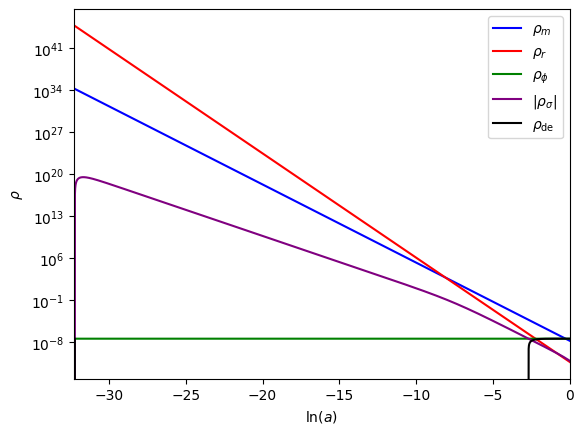

In [15]:

plt.semilogy(N_arr, rho_m_arr, label=r'$\rho_m$', color='blue')
plt.semilogy(N_arr, rho_r_arr, label=r'$\rho_r$', color='red')
plt.semilogy(N_arr, rho_phi_arr, label=r'$\rho_\phi$', color='green')
plt.semilogy(N_arr, np.abs(rho_sigma_arr), label=r'$|\rho_\sigma|$',color='purple')
plt.semilogy(N_arr, rho_phi_arr + rho_sigma_arr, label=r'$\rho_\text{de}$', color='black')
plt.legend()
plt.xlabel(r'$\ln(a)$')
plt.ylabel(r'$\rho$')
plt.xlim(-32.3,0)
plt.show()


#### Age of the Universe

The calculation is

$$ 
H(t) = \sqrt{\rho_{tot}} 
$$

$$ 
t_0 = \frac{1}{H_0} \int_{N_\text{ini}}^{N_0} \frac{dN}{E(N)} 
$$

where $E=H/H_0$ and $N=\ln(a)$

In [16]:
# --- Calculate Age of Universe ---

pc_per_ly = const.parsec/const.light_year
# Fundamental constants
km = 1.0e3                       # m
Mpc = 3.08567758149137e22        # m
sec_per_yr = 3.15576e7           # s
sec_per_Gyr = 1.0e9 * sec_per_yr

to_Gyr = 1 / H0_SI / sec_per_Gyr

def age_calculation(rhotot, delta):

    # Ht is stored in rho_tot_arr
    Ht = np.sqrt(rhotot)
    H_today_sim = Ht[-1] # Ht[-1] = H0_class = H0/c

    # Calculate E(z) = H(z)/H0 = Ht(N)/Ht(today)
    E_inv = H_today_sim / Ht

    # Integrate dN / E(z)
    dimensionless_age_integral = trapezoid(E_inv, N_arr)

    age_gyr = to_Gyr * dimensionless_age_integral
    print(f"Age Calculation with delta = {delta}")
    print(f"Hubble Time (1/H0): {to_Gyr:.4f} Gyr")
    print(f"Dimensionless Integral: {dimensionless_age_integral:.4f}")
    print(f"Age of the Universe: {age_gyr:.4f} Gyr")


In [17]:
age_calculation(rho_tot_arr, 0.1)

Age Calculation with delta = 0.1
Hubble Time (1/H0): 14.1709 Gyr
Dimensionless Integral: 0.9566
Age of the Universe: 13.5565 Gyr


In [18]:
rho_m_arr[-1]/rho_r_arr[-1]

np.float64(3333.3941611787213)

In [19]:
# --- Calculate Pressures ---

p_r_arr = rho_r_arr/3
p_m_arr = np.zeros_like(p_r_arr)
lambda_phi = cosmo.input_params['lambda_phi']

# Potential V(phi)
# Note: potential arg clipping to avoid overflow, consistent with ode_system
max_exp_arg = 700.0
arg_phi = -lambda_phi * phi_arr
arg_phi = np.clip(arg_phi, -max_exp_arg, max_exp_arg)
V_arr = V0_bestfit * np.exp(arg_phi)

# p_phi = (1/3) * (0.5 * phi'^2 / a^2 - V)
p_phi = (0.5 * phi_prime_arr**2 / a_arr**2 - V_arr) / 3.0

# p_sigma = (1/3) * (-0.5 * sigma'^2 / a^2)
p_sigma = -0.5 * sigma_prime_arr**2 / a_arr**2 / 3.0

print(f"Pressure p_phi (today): {p_phi[-1]:.4e}")
print(f"Pressure p_sigma (today): {p_sigma[-1]:.4e}")

# Check Total Pressure density? (Effective w)
# w = (p_phi + p_sigma) / (rho_phi + rho_sigma)
w_de_arr = (p_phi + p_sigma) / (rho_phi_arr + rho_sigma_arr)
w_eff_arr = (p_phi + p_sigma + p_m_arr + p_r_arr) / (rho_phi_arr + rho_sigma_arr + rho_m_arr + rho_r_arr)
print(f"Dark Energy Equation of State w (today): {w_de_arr[-1]:.4f}")
print(f"Effective w (today): {w_eff_arr[-1]:.4f}")


Pressure p_phi (today): -3.4503e-08
Pressure p_sigma (today): -7.2786e-12
Dark Energy Equation of State w (today): -0.9989
Effective w (today): -0.6892


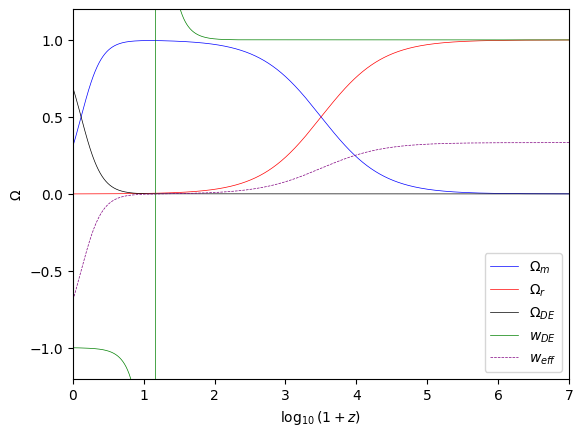

In [20]:
rho_de_arr = rho_phi_arr + rho_sigma_arr

z1 = -N_arr * np.log10(np.exp(1))

plt.plot(z1, rho_m_arr/rho_tot_arr, color='blue', linewidth=0.5, label=r'$\Omega_m$')
plt.plot(z1, rho_r_arr/rho_tot_arr, color='red', linewidth=0.5, label=r'$\Omega_r$')
plt.plot(z1, rho_de_arr/rho_tot_arr, color='black', linewidth=0.5, label=r'$\Omega_{DE}$')

plt.plot(z1, w_de_arr, color='green', linewidth=0.5, label=r'$w_{DE}$')
plt.plot(z1, w_eff_arr, color='purple', linewidth=0.5, label=r'$w_{eff}$', linestyle='--')
plt.xlim(0,7)
plt.ylim(-1.2,1.2)
plt.xlabel(r'$\log_{10}(1+z)$')
plt.ylabel(r'$\Omega$')
plt.legend()
plt.show()

In [ ]:
# --- Analytical Verification (RD scaling) ---
print("\n--- Analytical Verification ---")
q_analytical = Q(cosmo.input_params['delta'], cosmo.input_params['lambda_phi'])
omega_phi_RD_num = Omega_phi_arr[0]
print(f"Analytical Scaling Q(delta, lam): {q_analytical:.6e}")
print(f"Numerical Omega_phi at N_ini:   {omega_phi_RD_num:.6e}")
print(f"Difference: {abs(omega_phi_RD_num - q_analytical)/q_analytical:.2%}")

# Total Dark Energy Sum Check
omega_de_today = Omega_de_arr[-1]
omega_phi_today = Omega_phi_arr[-1]
omega_sigma_today = Omega_sigma_arr[-1]
print(f"\nDark Energy Status (Today):")
print(f"Omega_phi:   {omega_phi_today:.4f}")
print(f"Omega_sigma: {omega_sigma_today:.4f}")
print(f"Total Omega_de (Sum): {omega_phi_today + omega_sigma_today:.4f}")
print(f"Target Omega_de:      {omega_de_today:.4f}")